# Notebook 3 — BERT fine-tune (full) + LoRA

**Goal:** Fine-tune `bert-base-uncased` on the reddit `train` split, evaluate on the held-out
`test` split, save with `save_pretrained`, and (optionally) push to the HF Hub. Then train a
**LoRA** adapter on the same data and compare — the parameter-efficient fine-tuning study.

**Inputs:** `data/processed/reddit_eli5_{train,val,test}.parquet` (Notebook 1).

**Outputs:**
- `models/bert/` (full fine-tune: config + `model.safetensors` + tokenizer)
- `models/bert_lora/` (LoRA adapter only, ~5 MB)
- `results/per_epoch_metrics_bert.json`, `results/per_epoch_metrics_bert_lora.json`

**Run order (this notebook is long).** Measured wall-clock on an Apple M-series (MPS):
- **§1–§8 — full BERT, ~2.5 h** (~1.5 s/step at batch 16; early stopping often halts at epoch 2).
- **§9 — LoRA, ~2 h** (per-step is a touch faster, but it runs all 3 epochs — net similar).
- **§11 — HF Hub push is opt-in** and loads the saved models from disk, so it can be run on its
  own later (after `huggingface-cli login` + `PUSH_TO_HUB=True`) without re-running training.

**Locked from Notebook 1:** `max_length = 256`; headline metric **macro-F1**.

## 1. Setup, imports & device

All imports live in this one cell (project convention). Device selection puts **`mps` first**
(Apple Silicon), then `cuda`, then `cpu` — the common `"mps" if torch.cuda.is_available()` bug
never selects MPS. HF `Trainer` picks up MPS automatically.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["USE_TF"] = "0"   # transformers: PyTorch backend only — TF 2.21 + Keras 3 otherwise clashes

import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback,
    set_seed as hf_set_seed,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, f1_score,
)
from sklearn.utils.class_weight import compute_class_weight
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from huggingface_hub import ModelCard

warnings.filterwarnings("ignore")               # keep committed output clean + free of env paths

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd().name)


def set_all_seeds(seed: int = 42) -> None:
    """Seed every source of randomness used in this project."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    hf_set_seed(seed)


set_all_seeds(42)
sns.set_theme(style="whitegrid")

# Device: mps BEFORE the cuda check (the common "mps if cuda.is_available()" bug never picks MPS).
device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Training device:", device, "| torch", torch.__version__)

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256                                          # from Notebook 1 §5
HF_REPO_ID = "lilhuang15/bert-ai-text-detector-reddit"
LORA_REPO_ID = "lilhuang15/bert-ai-text-detector-reddit-lora"
PUSH_TO_HUB = False                                   # flip to True AFTER `huggingface-cli login`

Working directory: ai-generated-text-detector
Training device: mps | torch 2.12.0


## 2. Load reddit splits

In [2]:
train_df = pd.read_parquet("data/processed/reddit_eli5_train.parquet")
val_df   = pd.read_parquet("data/processed/reddit_eli5_val.parquet")
test_df  = pd.read_parquet("data/processed/reddit_eli5_test.parquet")
print("shapes:", train_df.shape, val_df.shape, test_df.shape)
print("train label balance:", train_df["label"].value_counts(normalize=True).round(3).to_dict())

shapes: (47596, 3) (10200, 3) (10200, 3)
train label balance: {0: 0.755, 1: 0.245}


## 3. Tokenizer, model, and tokenized HF Datasets

Tokenize with truncation to `MAX_LEN=256` but **no padding** — `DataCollatorWithPadding` pads
each batch dynamically (faster than padding everything to 256). The collator also renames the
`label` column to `labels` for the model.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df[["text", "label"]],   preserve_index=False).map(tokenize, batched=True)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]],  preserve_index=False).map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(train_ds)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/47596 [00:00<?, ? examples/s]

Map:   0%|          | 0/10200 [00:00<?, ? examples/s]

Map:   0%|          | 0/10200 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 47596
})


## 4. `compute_metrics`

`f1` here is the **binary** F1 of the positive class (label 1 = AI), used to select the best
checkpoint (`metric_for_best_model="f1"`). We report **macro-F1** as the headline.

> **Imbalance → class weights (consistent with TF-IDF + LSTM).** Instead of a plain `Trainer`
> we use a **`WeightedTrainer`** (defined in §5) that applies **balanced** class weights in the
> loss — the same 75/25 correction as the other two models, so the imbalance is handled
> *uniformly across all three trained models* (a cleaner, easier-to-defend story than weighting
> some models but not BERT).

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }

## 5. `TrainingArguments` + `WeightedTrainer`

Two deliberate choices (both flagged):
- **`WeightedTrainer`** — a `Trainer` subclass that puts **balanced** class weights in the loss
  (the imbalance correction; consistent with TF-IDF + LSTM — see §4).
- **`processing_class=tokenizer`** — the `tokenizer=` arg to `Trainer` is deprecated in
  transformers 4.57.

⚠️ **Speed on MPS (measured).** BERT on MPS is slow — **~1.5 s/step at batch 16 → ~2.5 h for the
run** (early stopping often halts at epoch 2). **Keep `per_device_train_batch_size=16`:** batch 32
was measured *slower* on a 16 GB Mac (~6 s/step — memory pressure, not a win). To go faster, drop
to **2 epochs** or a smaller encoder. On **8 GB**, drop the batch to **8** if MPS OOMs.

In [5]:
# Balanced class weights for the 75/25 imbalance (same correction as TF-IDF/LSTM).
# float32 because Apple MPS has no float64.
class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.array([0, 1]), y=train_df["label"].to_numpy()),
    dtype=torch.float32,
)
print("class weights [human, ai]:", [round(w, 3) for w in class_weights.tolist()])


class WeightedTrainer(Trainer):
    """Trainer with balanced class-weighted cross-entropy (handles the 75/25 imbalance)."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights.to(outputs.logits.device)
        )
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="models/bert_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,        # keep 16 (batch 32 was slower here — memory pressure); 8 if 8GB OOM
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    seed=42,
    report_to="none",
    push_to_hub=False,                     # push is a separate opt-in step (see §11)
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,            # 2026: replaces the deprecated tokenizer= arg
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
print("WeightedTrainer ready. Training on:", trainer.args.device)

class weights [human, ai]: [0.662, 2.041]
WeightedTrainer ready. Training on: mps


## 6. Train 

`load_best_model_at_end=True` restores the best-`f1` checkpoint after training.

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.047600,0.012635,0.994706,0.989303,0.979600,0.999200
2,0.000000,0.024303,0.994510,0.988915,0.978457,0.999600


TrainOutput(global_step=5950, training_loss=0.03515251402511797, metrics={'train_runtime': 8786.642, 'train_samples_per_second': 16.251, 'train_steps_per_second': 1.016, 'total_flos': 1.245904024891872e+16, 'train_loss': 0.03515251402511797, 'epoch': 2.0})

## 7. Evaluate on the held-out TEST split (headline = macro-F1)

In [14]:
pred = trainer.predict(test_ds)
bert_preds = np.argmax(pred.predictions, axis=-1)
y_test = test_df["label"].to_numpy()

print("=== BERT full fine-tune  —  reddit TEST ===")
print(classification_report(y_test, bert_preds, target_names=["human", "ai"], digits=4))
bert_macro_f1 = f1_score(y_test, bert_preds, average="macro")
print("macro-F1 (headline):", round(bert_macro_f1, 4))
print("\nconfusion matrix [rows=true, cols=pred]:")
print(confusion_matrix(y_test, bert_preds))

=== BERT full fine-tune  —  reddit TEST ===
              precision    recall  f1-score   support

       human     0.9996    0.9940    0.9968      7701
          ai     0.9819    0.9988    0.9903      2499

    accuracy                         0.9952     10200
   macro avg     0.9908    0.9964    0.9935     10200
weighted avg     0.9953    0.9952    0.9952     10200

macro-F1 (headline): 0.9935

confusion matrix [rows=true, cols=pred]:
[[7655   46]
 [   3 2496]]


## 8. Save the model + per-epoch metrics + curves

In [15]:
# 8a. Save full model + tokenizer with save_pretrained (NOT torch.save of the whole object).
trainer.save_model("models/bert/")
tokenizer.save_pretrained("models/bert/")
print("saved models/bert/ ->", sorted(p.name for p in Path("models/bert").iterdir()))

saved models/bert/ -> ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']


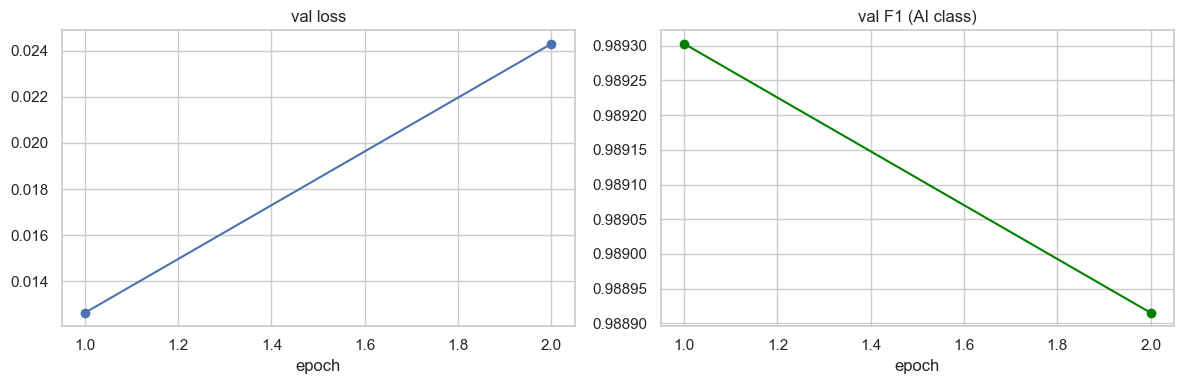

saved results/per_epoch_metrics_bert.json | eval epochs: [1.0, 2.0]


In [16]:
# 8b. Per-epoch metrics from trainer.state.log_history + loss/F1 curves.
Path("results").mkdir(exist_ok=True)
with open("results/per_epoch_metrics_bert.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

evals = [e for e in trainer.state.log_history if "eval_f1" in e]
epochs = [e["epoch"] for e in evals]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, [e["eval_loss"] for e in evals], marker="o")
ax[0].set_title("val loss"); ax[0].set_xlabel("epoch")
ax[1].plot(epochs, [e["eval_f1"] for e in evals], marker="o", color="green")
ax[1].set_title("val F1 (AI class)"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()
print("saved results/per_epoch_metrics_bert.json | eval epochs:", epochs)

## 9. LoRA variant — parameter-efficient fine-tuning study

Train a LoRA adapter on the **same** data (fresh base BERT, LoRA on attention Q & V), then
compare to the full fine-tune. Expectation: within a few points of the full F1 at **~0.27%** of
the parameters (≈297K of 110M). We still **deploy the full model** — LoRA's win is training
efficiency and a ~5 MB adapter, not inference.

▶️ Run this section only **after** the full BERT above has finished and you've reported its F1.

In [7]:
# 9a. Fresh base BERT + LoRA config (adapts the original weights, not the fine-tuned ones).
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                               # rank (typical 4-16)
    lora_alpha=16,                     # scaling (≈2x rank)
    lora_dropout=0.1,
    target_modules=["query", "value"], # LoRA on attention Q and V projections
    bias="none",
)
peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()   # ~297K trainable (0.27%): LoRA on Q,V + the SEQ_CLS head

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


In [8]:
# 9b. Same TrainingArguments (different output dir + higher LR, standard for LoRA).
lora_training_args = TrainingArguments(
    output_dir="models/bert_lora_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,        # -> 8 if OOM (same as full BERT)
    per_device_eval_batch_size=32,
    learning_rate=3e-4,                    # LoRA uses a higher LR than full fine-tune
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    seed=42,
    report_to="none",
)

lora_trainer = WeightedTrainer(            # same balanced class-weighted loss as the full model
    model=peft_model,
    args=lora_training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
lora_trainer.train()      

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.032300,0.042918,0.985490,0.971240,0.944088,1.000000
2,0.002900,0.050817,0.988333,0.976744,0.954545,1.000000
3,0.000200,0.041001,0.989804,0.979616,0.960046,1.000000


TrainOutput(global_step=8925, training_loss=0.02708922402433991, metrics={'train_runtime': 7231.3531, 'train_samples_per_second': 19.746, 'train_steps_per_second': 1.234, 'total_flos': 1.875527178430272e+16, 'train_loss': 0.02708922402433991, 'epoch': 3.0})

In [12]:
# 9c. Save the adapter only (~5 MB). (HF Hub push is the consolidated opt-in step in §11.)
peft_model.save_pretrained("models/bert_lora/")
print("saved models/bert_lora/ ->", sorted(p.name for p in Path("models/bert_lora").iterdir()))

saved models/bert_lora/ -> ['README.md', 'adapter_config.json', 'adapter_model.safetensors']


In [10]:
# 9d. Evaluate LoRA on the same TEST split (headline = macro-F1).
lora_pred = lora_trainer.predict(test_ds)
lora_preds = np.argmax(lora_pred.predictions, axis=-1)

print("=== BERT + LoRA  —  reddit TEST ===")
print(classification_report(y_test, lora_preds, target_names=["human", "ai"], digits=4))
lora_macro_f1 = f1_score(y_test, lora_preds, average="macro")
print("macro-F1 (headline):", round(lora_macro_f1, 4))

trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in peft_model.parameters())
with open("results/per_epoch_metrics_bert_lora.json", "w") as f:
    json.dump({"log_history": lora_trainer.state.log_history,
               "test_macro_f1": float(lora_macro_f1),
               "trainable_params": int(trainable), "total_params": int(total)}, f, indent=2)
print(f"\nLoRA trainable: {trainable:,} / {total:,} ({trainable/total:.2%})")
print("saved results/per_epoch_metrics_bert_lora.json")

=== BERT + LoRA  —  reddit TEST ===
              precision    recall  f1-score   support

       human     0.9997    0.9881    0.9939      7701
          ai     0.9645    0.9992    0.9815      2499

    accuracy                         0.9908     10200
   macro avg     0.9821    0.9936    0.9877     10200
weighted avg     0.9911    0.9908    0.9908     10200

macro-F1 (headline): 0.9877

LoRA trainable: 296,450 / 109,780,228 (0.27%)
saved results/per_epoch_metrics_bert_lora.json


## 10. Verification checklist

In [11]:
# Programmatic verification checks.
ok = True

bert_files = set(p.name for p in Path("models/bert").iterdir()) if Path("models/bert").exists() else set()
need_bert = {"config.json", "model.safetensors", "tokenizer.json", "vocab.txt", "special_tokens_map.json"}
print("models/bert/ has required files:", need_bert <= bert_files, "| missing:", need_bert - bert_files)
ok &= need_bert <= bert_files

lora_files = set(p.name for p in Path("models/bert_lora").iterdir()) if Path("models/bert_lora").exists() else set()
need_lora = {"adapter_config.json", "adapter_model.safetensors"}
print("models/bert_lora/ has required files:", need_lora <= lora_files, "| missing:", need_lora - lora_files)
ok &= need_lora <= lora_files

# Reload checks
_reb = AutoModelForSequenceClassification.from_pretrained("models/bert/")
print("reload BERT: OK")
_base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
_rel = PeftModel.from_pretrained(_base, "models/bert_lora/")
print("reload LoRA adapter: OK")

for fp in ["results/per_epoch_metrics_bert.json", "results/per_epoch_metrics_bert_lora.json"]:
    print(f"{fp} exists:", Path(fp).exists()); ok &= Path(fp).exists()

print("\nVERIFICATION:", "ALL PASS ✅" if ok else "SOMETHING MISSING ❌")
print("(HF Hub push is separate — confirm in browser if you enabled PUSH_TO_HUB.)")

models/bert/ has required files: True | missing: set()
models/bert_lora/ has required files: True | missing: set()
reload BERT: OK


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reload LoRA adapter: OK
results/per_epoch_metrics_bert.json exists: True
results/per_epoch_metrics_bert_lora.json exists: True

VERIFICATION: ALL PASS ✅
(HF Hub push is separate — confirm in browser if you enabled PUSH_TO_HUB.)


## 11. Push to HF Hub — opt-in *(loads the saved models from disk, then pushes)*

This is the **only** publish step, and it is **self-contained**: it loads `models/bert/` and
`models/bert_lora/` from disk and pushes both — so it does **not** depend on the training cells
above still being in memory. To publish later, just run **§1 (setup)** and then this cell.

One-time auth: `pip install -U huggingface_hub`, then `huggingface-cli login` (paste a **Write**
token). Then set `PUSH_TO_HUB = True` in §1 and run this cell. It is gated on `PUSH_TO_HUB` so
**Restart & Run All never fails** on a machine that isn't logged in.

In [ ]:
# Self-contained publish: load the saved models from disk and push both to the HF Hub.
# Independent of the training cells above — run §1 + this cell to publish later (no retraining).
if PUSH_TO_HUB:
    # --- full fine-tuned BERT (the deployed model) ---
    bert = AutoModelForSequenceClassification.from_pretrained("models/bert/")
    bert_tok = AutoTokenizer.from_pretrained("models/bert/")
    bert.push_to_hub(HF_REPO_ID)
    bert_tok.push_to_hub(HF_REPO_ID)
    card = ModelCard.from_template(
        card_data={"language": "en", "license": "cc-by-sa-4.0",
                   "tags": ["text-classification", "ai-detection"]},
        model_id=HF_REPO_ID,
        model_description="BERT-uncased fine-tuned on HC3 reddit_eli5 for AI-generated text detection.",
    )
    card.push_to_hub(HF_REPO_ID)
    print("pushed full model ->", f"https://huggingface.co/{HF_REPO_ID}")

    # --- LoRA adapter (comparison study, not deployed) ---
    _base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    lora = PeftModel.from_pretrained(_base, "models/bert_lora/")
    lora.push_to_hub(LORA_REPO_ID)
    print("pushed LoRA adapter ->", f"https://huggingface.co/{LORA_REPO_ID}")
else:
    print("PUSH_TO_HUB is False — skipping. (Set it True in §1 after `huggingface-cli login`.)")

## Summary

- Full BERT macro-F1 vs the baselines (TF-IDF 0.982, LSTM 0.968) — record in the pipeline report.
- LoRA macro-F1 + trainable-% — the PEFT story (≈full performance at ~0.27% of the params).
- `models/bert/` is the **deployed** model (Notebook 4 + the Streamlit app load it); `models/`
  is gitignored (weights live on HF Hub).

Next: `04_llm_comparison_crossdomain_errors.ipynb`.